# Amazon Review Intelligence — 03. Topics & Insights

What happens in this notebook:
- extract 12 review topics with LDA and give them business-friendly names;
- find reviews where the star rating contradicts the text (e.g. 1★ with a positive review);
- combine sentiment, topics and metadata: the most problematic topics, helpful votes, monthly trends;
- build summary visualizations for the dashboard;
- extract topics a second way — with BERTopic — and explain why LDA remains the dashboard model.

**Input:** `data/reviews_clean.parquet` ([notebook 01](01_data_eda.ipynb)); `data/split.parquet` and `models/svc_pipeline.joblib` ([notebook 02](02_sentiment_models.ipynb)).

---

# Amazon Review Intelligence — 03. Темы и инсайты

Что происходит в этом ноутбуке:
- выделяем 12 тем отзывов с помощью LDA и даём им понятные бизнес-названия;
- ищем отзывы, где звёздный рейтинг противоречит тексту (например, 1★ с позитивным отзывом);
- соединяем тональность, темы и метаданные: самые проблемные темы, голоса полезности, тренды по месяцам;
- строим сводные визуализации для дашборда;
- выделяем темы вторым способом — BERTopic — и объясняем, почему в дашборде остался LDA.

**Вход:** `data/reviews_clean.parquet` ([ноутбук 01](01_data_eda.ipynb)); `data/split.parquet` и `models/svc_pipeline.joblib` ([ноутбук 02](02_sentiment_models.ipynb)).

In [1]:
# All paths in the project are relative to the repo root (data/, models/):
# the notebook lives in notebooks/, so we move one level up
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

# Imports and environment setup
import re
import joblib

from html import unescape

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Quality metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# BERTopic (section 3.5)
import torch
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Pandas display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Matplotlib plot style
plt.style.use("ggplot")

In [2]:
# Data from notebook 01; split and sentiment model from notebook 02
reviews = pd.read_parquet("data/reviews_clean.parquet")
split = pd.read_parquet("data/split.parquet")["split"]

# Test set — exactly the split saved by notebook 02
test_idx = split.index[split == "test"]
X_test = reviews.loc[test_idx, "clean_text"]
y_test = reviews.loc[test_idx, "sentiment_label"]

# Final sentiment model: calibrated LinearSVC from notebook 02
pipe_svc = joblib.load("models/svc_pipeline.joblib")

print(f"reviews: {reviews.shape}, test: {len(X_test)}")

reviews: (460697, 14), test: 92140


## 3.1 Topic Modeling (LDA)

We discover hidden topics in the reviews without any labels (unsupervised learning): which product categories and problems customers actually write about.

Находим скрытые темы в отзывах без какой-либо разметки (обучение без учителя): о каких категориях товаров и проблемах покупатели реально пишут.

In [3]:
# Sample 200k reviews for topic modeling: enough for good topics while saving memory and training time
topic_reviews = reviews.sample(
    200_000,
    random_state=42
)

In [4]:
# Use the cleaned text without stop words
topic_texts = topic_reviews[
    "clean_text_no_stopwords"
]

topic_texts.head()

157817                                                                                                                            love best purchase great pancake waffle batter straining kefir grains best size
220628                                                                                         great works great straw storage not alot say heavy weight straws look beautiful lid lifts expose straws dispensing
311986                                                                                                                           easy use like easier use baking soda fits better work really like bags refreshed
206500                                                                           shines polished stone nicely beautifully shined granite marble smells great highly recommend product works great stainless steel
161174    great tub shower cleaning purchased getting older reaching tub scrub tile surround getting harder brush easily reach corners nooks crannies fixtures h

In [5]:
# Build a CountVectorizer for topic modeling
# Use unigrams and bigrams
# Drop overly rare and overly frequent words

topic_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.5,
    max_features=10_000
)

In [6]:
# Transform texts into a count-based feature matrix
topic_matrix = topic_vectorizer.fit_transform(
    topic_texts
)

topic_matrix.shape

(200000, 10000)

In [7]:
# Check the CountVectorizer vocabulary size
len(topic_vectorizer.get_feature_names_out())

10000

For topic modeling we use CountVectorizer instead of TF-IDF: LDA works with raw word counts and looks at which words appear together within a document. Unigrams and bigrams help the model capture topics and customer pain points more precisely.

Для выделения тем используем CountVectorizer вместо TF-IDF: LDA работает с обычными частотами слов и смотрит, какие слова встречаются вместе внутри документа. Слова и пары слов помогают модели точнее улавливать темы и проблемы покупателей.

In [8]:
# Path to the saved LDA model
lda_model_path = "models/lda_model.joblib"

# Build the LDA model
lda_model = LatentDirichletAllocation(
    n_components=12,
    random_state=42,
    learning_method="batch",
    max_iter=30
)

# Load the model if it already exists
if os.path.exists(lda_model_path):

    lda_model = joblib.load(
        lda_model_path
    )

    print("LDA model loaded")

# Otherwise train and save
else:

    lda_model.fit(topic_matrix)

    # Save the LDA model
    joblib.dump(
        lda_model,
        lda_model_path
    )

    # Save the CountVectorizer
    joblib.dump(
        topic_vectorizer,
        "models/topic_vectorizer.joblib"
    )

    print("LDA model trained and saved")

LDA model loaded


In [9]:
# Get the words from the CountVectorizer
feature_names = topic_vectorizer.get_feature_names_out()

In [10]:
# Helper: print the top words of each topic
def print_topics(model, feature_names, n_top_words=10):

    for topic_idx, topic in enumerate(model.components_):

        top_words = [
            feature_names[i]
            for i in topic.argsort()[:-n_top_words - 1:-1]
        ]

        print(f"\nTopic #{topic_idx + 1}")
        print(", ".join(top_words))

In [11]:
# Print the top words per topic
print_topics(
    lda_model,
    feature_names,
    n_top_words=15
)


Topic #1
puppy, good bad, pretty durable, gray color, prices, prone, hammer, valuable, good option, net, arrived today, burned, indicator, heavy not, excelente

Topic #2
nice weight, displays, family room, island, vaccum, air frying, lifted, updated, levels, tie, right not, works described, underside, gray color, jars

Topic #3
nice weight, desk, jars, detailed, displays, lifted, dock, super comfortable, work home, tie, prices, updated, bought set, moderate, radio

Topic #4
lifted, nice weight, self, updated, haven, grooves, guess not, disc, net, weight sturdy, glass containers, kitchen drawer, herbal, settled, good bad

Topic #5
bones, nylon, year warranty, needing, good work, love smell, yeah, love shape, lot weight, small items, cutting, tie, properly, gift got, self

Topic #6
lot weight, gray color, net, curtains not, beautiful addition, long, looking like, peace mind, radio, gift got, lip, transfer, machine wash, jars, self

Topic #7
nice weight, updated, bags just, bagels, water

In [12]:
# Business labels for topic interpretation.
# IMPORTANT: LDA topic indices are not stable across retrainings — the labels were matched
# to the actual top words from print_topics() above. If LDA is retrained,
# recheck the mapping against the new print_topics() output.
topic_labels = {
    0: "Ease of Use & Cleaning",
    1: "Bedding & Sleep",
    2: "Bath & Soft Furnishings",
    3: "Home Appliances (Fans & Vacuums)",
    4: "Price, Value & Delivery Issues",
    5: "Furniture & Cutlery",
    6: "Size, Fit & Storage",
    7: "Cookware & Kitchen",
    8: "Drinkware & Beverages",
    9: "Gifts & Recommendations",
    10: "Appearance & Design",
    11: "Complaints & Malfunctions"
}

In [13]:
# Get the topic distribution for each review
topic_probabilities = lda_model.transform(
    topic_matrix
)

topic_probabilities.shape

(200000, 12)

In [14]:
# Find the dominant topic of each review
dominant_topics = topic_probabilities.argmax(axis=1)

dominant_topics[:10]

array([4, 1, 6, 3, 1, 5, 2, 6, 1, 8])

In [15]:
# Add the dominant topic to the DataFrame
topic_reviews = topic_reviews.copy()

topic_reviews["dominant_topic"] = dominant_topics

topic_reviews[
    ["clean_text_no_stopwords", "dominant_topic"]
].head()

,clean_text_no_stopwords,dominant_topic
157817,love best purchase great pancake waffle batter straining kefir grains best size,4
220628,great works great straw storage not alot say heavy weight straws look beautiful lid lifts expose straws dispensing,1
311986,easy use like easier use baking soda fits better work really like bags refreshed,6
206500,shines polished stone nicely beautifully shined granite marble smells great highly recommend product works great stainless steel,3
161174,great tub shower cleaning purchased getting older reaching tub scrub tile surround getting harder brush easily reach corners nooks crannies fixtures high low makes cleaning shower tub task not avo...,1


In [16]:
# Add business labels to the DataFrame
topic_reviews["topic_label"] = topic_reviews[
    "dominant_topic"
].map(topic_labels)

topic_reviews[
    ["dominant_topic", "topic_label"]
].head()

,dominant_topic,topic_label
157817,4,"Price, Value & Delivery Issues"
220628,1,Bedding & Sleep
311986,6,"Size, Fit & Storage"
206500,3,Home Appliances (Fans & Vacuums)
161174,1,Bedding & Sleep


In [17]:
# Add topic labels back to the main DataFrame
reviews.loc[
    topic_reviews.index,
    "dominant_topic"
] = topic_reviews["dominant_topic"]

reviews.loc[
    topic_reviews.index,
    "topic_label"
] = topic_reviews["topic_label"]

reviews[
    ["dominant_topic", "topic_label"]
].head()

,dominant_topic,topic_label
0,2.0,Bath & Soft Furnishings
1,NaN,NaN
2,1.0,Bedding & Sleep
3,NaN,NaN
4,NaN,NaN


In [18]:
# Count reviews per topic
topic_frequency = topic_reviews[
    "topic_label"
].value_counts()

topic_frequency

topic_label
Bath & Soft Furnishings             65139
Bedding & Sleep                     19080
Drinkware & Beverages               17982
Furniture & Cutlery                 15887
Complaints & Malfunctions           15031
Size, Fit & Storage                 14504
Home Appliances (Fans & Vacuums)    12519
Appearance & Design                 11260
Cookware & Kitchen                  11180
Price, Value & Delivery Issues      10437
Ease of Use & Cleaning               3960
Gifts & Recommendations              3021
Name: count, dtype: int64

In [19]:
# Convert topic counts to a DataFrame
topic_frequency_df = topic_frequency.reset_index()

topic_frequency_df.columns = [
    "topic_label",
    "count"
]

topic_frequency_df

,topic_label,count
0,Bath & Soft Furnishings,65139
1,Bedding & Sleep,19080
2,Drinkware & Beverages,17982
3,Furniture & Cutlery,15887
4,Complaints & Malfunctions,15031
5,"Size, Fit & Storage",14504
6,Home Appliances (Fans & Vacuums),12519
7,Appearance & Design,11260
8,Cookware & Kitchen,11180
9,"Price, Value & Delivery Issues",10437


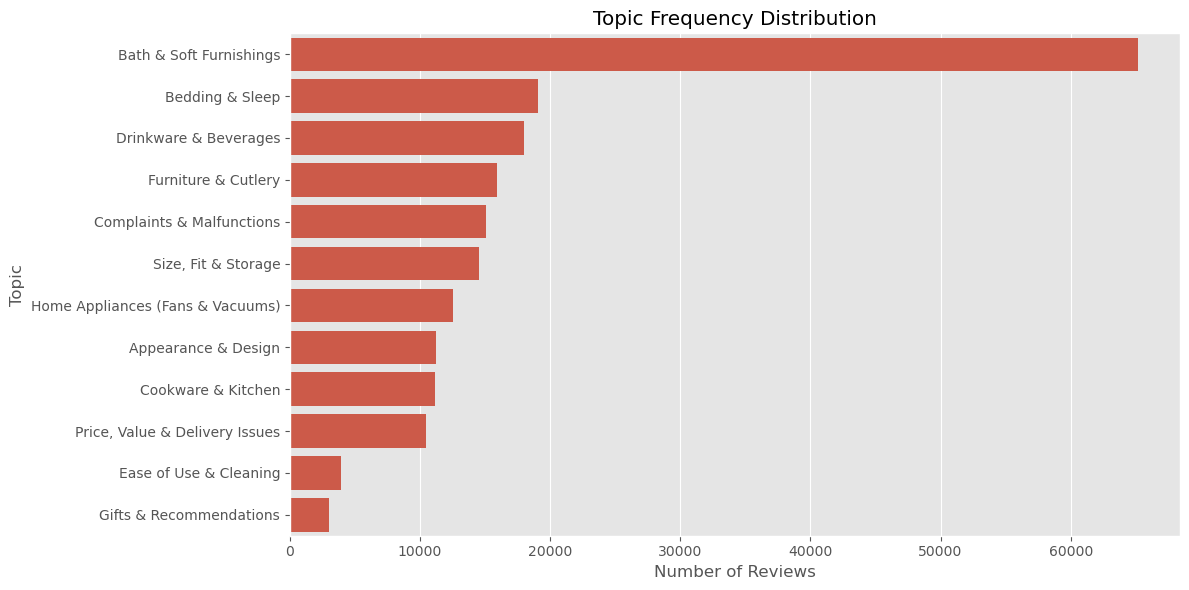

In [20]:
# Plot the topic distribution
plt.figure(figsize=(12, 6))

sns.barplot(
    data=topic_frequency_df,
    x="count",
    y="topic_label"
)

plt.title("Topic Frequency Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

In [21]:
topic_sentiment = pd.crosstab(
    reviews["topic_label"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

topic_sentiment.round(2)

sentiment_label,negative,neutral,positive
topic_label,,,
Appearance & Design,9.01,6.69,84.30
Bath & Soft Furnishings,18.05,9.78,72.17
Bedding & Sleep,9.10,6.15,84.75
Complaints & Malfunctions,8.60,6.07,85.34
Cookware & Kitchen,5.14,4.64,90.21
Drinkware & Beverages,11.56,8.93,79.52
Ease of Use & Cleaning,7.15,6.16,86.69
Furniture & Cutlery,3.95,2.95,93.09
Gifts & Recommendations,3.38,2.45,94.17


> Topic sentiment shares below are computed on the reproducible 200k sample used to train LDA, not on the full dataset.

Topic-level sentiment differs sharply between topics.

The most problematic topics:
- `Price, Value & Delivery Issues` — 41.8% negative and only 48.6% positive (complaints about price/value, cheap materials, delivery and packaging);
- `Complaints & Malfunctions` — 34.1% negative and the highest neutral share (20.8%); these are negation-heavy reviews (`does not work`, `did not`) where the product failed expectations.

The most positive topics (>92% positive): `Gifts & Recommendations` (98.4%), `Size, Fit & Storage` (93.7%), `Ease of Use & Cleaning` (93.6%), `Appearance & Design` (92.3%).

So negativity concentrates not around a product category but around "price / value / delivery" and "breakage / unmet expectations" — these are the main customer pain points. Combining topics with sentiment pinpoints them precisely.

> Доли тональности по темам ниже рассчитаны на воспроизводимой подвыборке 200 тысяч отзывов, на которой обучалась LDA, а не на всём датасете.

Тональность сильно различается между темами.

Самые проблемные темы:
- `Price, Value & Delivery Issues` — 41.8% негатива и лишь 48.6% позитива (жалобы на цену и ценность, дешёвый материал, доставку и упаковку);
- `Complaints & Malfunctions` — 34.1% негатива и самая высокая доля neutral (20.8%); это отзывы с отрицаниями (`does not work`, `did not`), где товар не оправдал ожиданий.

Самые позитивные темы (>92% позитива): `Gifts & Recommendations` (98.4%), `Size, Fit & Storage` (93.7%), `Ease of Use & Cleaning` (93.6%), `Appearance & Design` (92.3%).

То есть негатив концентрируется не вокруг товарной категории, а вокруг тем «цена / ценность / доставка» и «поломки / несоответствие ожиданиям» — это и есть главные болевые точки покупателей. Связка тем с тональностью позволяет находить их точечно.

### Topic Trends Over Time

We track how topic shares change month by month — whether customer attention shifts between topics over time.

Смотрим, как доли тем меняются по месяцам — смещается ли внимание покупателей между темами со временем.

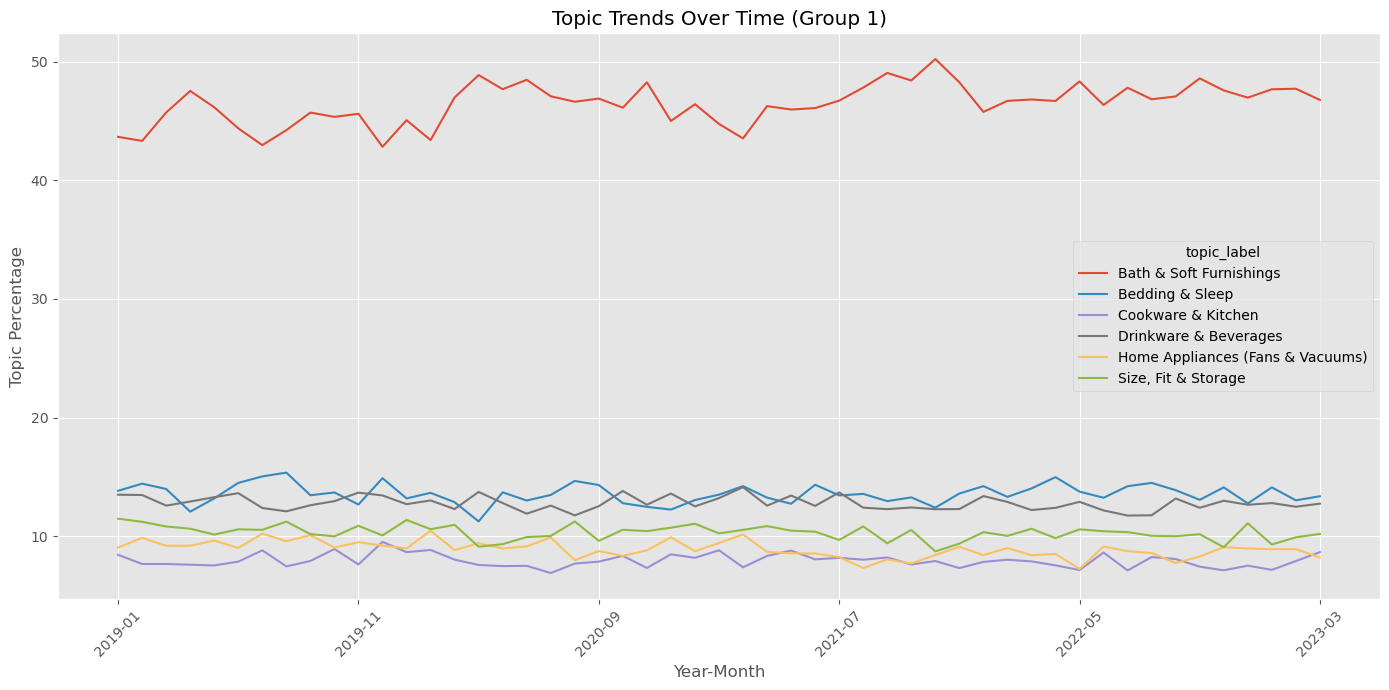

In [22]:
# Get the list of topics
topics = reviews["topic_label"].dropna().unique()

# First 6 topics
topics_group_1 = topics[:6]

# Filter the DataFrame
reviews_group_1 = reviews[
    reviews["topic_label"].isin(topics_group_1)
]

# Normalized topic distribution over time
topic_time_group_1 = pd.crosstab(
    reviews_group_1["year_month"],
    reviews_group_1["topic_label"],
    normalize="index"
) * 100

# Plot
topic_time_group_1.plot(
    figsize=(14, 7)
)

plt.title("Topic Trends Over Time (Group 1)")
plt.xlabel("Year-Month")
plt.ylabel("Topic Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

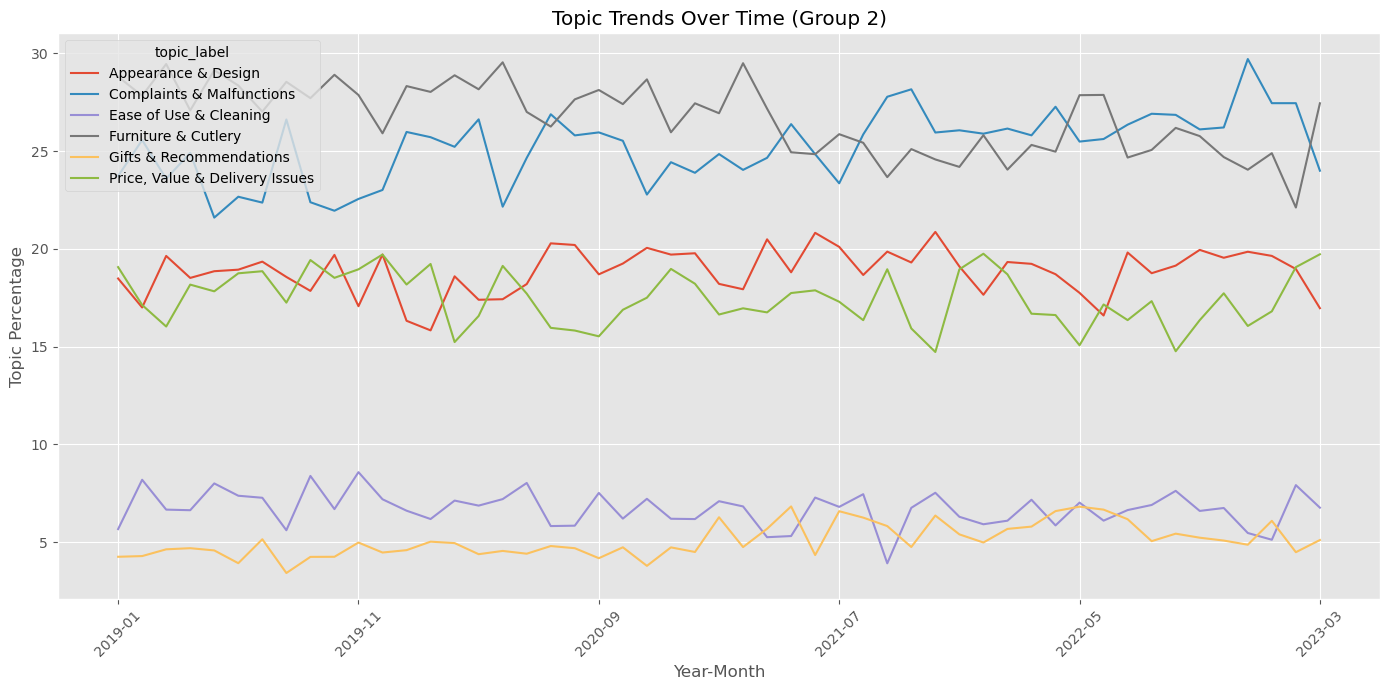

In [23]:
# Next 6 topics
topics_group_2 = topics[6:]

# Filter the DataFrame
reviews_group_2 = reviews[
    reviews["topic_label"].isin(topics_group_2)
]

# Normalized topic distribution over time
topic_time_group_2 = pd.crosstab(
    reviews_group_2["year_month"],
    reviews_group_2["topic_label"],
    normalize="index"
) * 100

# Plot
topic_time_group_2.plot(
    figsize=(14, 7)
)

plt.title("Topic Trends Over Time (Group 2)")
plt.xlabel("Year-Month")
plt.ylabel("Topic Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Topic modeling: conclusion

LDA produced 12 stable topics in Amazon Home & Kitchen reviews — from product categories (`Bedding & Sleep`, `Cookware & Kitchen`, `Drinkware & Beverages`, `Bath & Soft Furnishings`, `Home Appliances`, `Furniture & Cutlery`) to cross-cutting experience topics (`Ease of Use & Cleaning`, `Appearance & Design`, `Size, Fit & Storage`, `Gifts & Recommendations`) and problem topics (`Price, Value & Delivery Issues`, `Complaints & Malfunctions`).

The most negative topics are `Price, Value & Delivery Issues` (41.8% negative) and `Complaints & Malfunctions` (34.1%), while `Gifts & Recommendations` and `Ease of Use & Cleaning` are almost entirely positive (>93%). Topic shares are broadly stable over time.

Note: topics and sentiment shares are computed on the reproducible 200k training sample. LDA topic indices are not stable across retrainings — the business names were assigned manually from the top words and must be rechecked if the model is retrained.

### Вывод по темам

LDA выделил 12 устойчивых тем в отзывах Amazon Home & Kitchen — от товарных категорий (`Bedding & Sleep`, `Cookware & Kitchen`, `Drinkware & Beverages`, `Bath & Soft Furnishings`, `Home Appliances`, `Furniture & Cutlery`) до сквозных тем опыта (`Ease of Use & Cleaning`, `Appearance & Design`, `Size, Fit & Storage`, `Gifts & Recommendations`) и проблемных тем (`Price, Value & Delivery Issues`, `Complaints & Malfunctions`).

Самые негативные темы — `Price, Value & Delivery Issues` (41.8% негатива) и `Complaints & Malfunctions` (34.1%), а `Gifts & Recommendations` и `Ease of Use & Cleaning` почти полностью позитивны (>93%). Доли тем во времени в целом стабильны.

Примечание: темы и доли тональности рассчитаны на воспроизводимой обучающей подвыборке 200 тысяч отзывов. Индексы тем LDA не сохраняются между переобучениями — бизнес-названия сопоставлены вручную по топ-словам, и при переобучении модели их нужно перепроверить.

## 3.2 Sentiment-Rating Mismatch Analysis

We look for reviews where the star rating and the text disagree: 5★ with a negative text or 1★ with a positive one. Sentiment is predicted by the final model from notebook 02 (calibrated LinearSVC) on the test set.

Ищем отзывы, в которых звёздный рейтинг и текст не совпадают: 5★ с негативным текстом или 1★ с позитивным. Тональность предсказывает финальная модель из ноутбука 02 (калиброванный LinearSVC) на тестовой выборке.

In [24]:
# The mismatch analysis uses the FINAL (deployment) model — calibrated LinearSVC,
# so the conclusions apply to the production model, not the Logistic Regression baseline.
final_model = pipe_svc

y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)
confidence_final = y_proba_final.max(axis=1)

final_predictions_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "predicted_label": y_pred_final,
    "confidence": confidence_final,
    "rating": reviews.loc[X_test.index, "rating"].values
})

final_predictions_df.head()

,text,true_label,predicted_label,confidence,rating
0,perfect this is perfect for a small sink i purchased for our camper i am very happy with it,positive,positive,0.997190,5
1,nice gift set this is a cute set to give to the lady in your life a nice mug and candle,positive,positive,0.942919,5
2,sturdy versatile storage totes 5 16 update i received the 3 small brown totes today i took a few before and after photos of the bookcase i ordered them for and a few pics comparing them to the bro...,positive,positive,0.977745,5
3,so well made my favorite pillow case of all time so soft and comfortable but not slippery like satin where you have to chase your pillow all over the bed,positive,positive,0.875523,5
4,durable and looks good i have used a styrofoam version of this for years and needed something that would stand up to almost daily use and that did not look like it belonged at a picnic this is str...,positive,positive,0.955010,5


In [25]:
# Model confidence threshold.
# predicted_label is only an ESTIMATE of sentiment (macro-F1 ~ 0.66), so a
# "5 stars + negative" case can be a real rating-text mismatch
# or just a model error. Filtering out low-confidence predictions keeps
# the more plausible mismatch cases and avoids selling model noise as insight.
CONFIDENCE_THRESHOLD = 0.70

In [26]:
# Confidence distribution over the test set
final_predictions_df["confidence"].describe()

count    92140.000000
mean         0.885842
std          0.146015
min          0.334856
25%          0.855264
50%          0.952817
75%          0.981481
max          0.999862
Name: confidence, dtype: float64

In [27]:
# 5 stars + predicted negative
mismatch_5_negative = final_predictions_df[
    (final_predictions_df["rating"] == 5) &
    (final_predictions_df["predicted_label"] == "negative")
]

# High-confidence subset: likely real mismatches, not model errors
mismatch_5_negative_hc = mismatch_5_negative[
    mismatch_5_negative["confidence"] >= CONFIDENCE_THRESHOLD
]

mismatch_5_negative_hc.head(30)

,text,true_label,predicted_label,confidence,rating
855,not for home grown i rarely give bad reviews and i am not starting now i am sure as most on here say it is dandy for carbon copy el perecto hothouse tomatoes however for home grown i found it pret...,positive,negative,0.752743,5
2064,very unhappy the 1st one i receive did not work properly and 2nd one worked great but water collects on the top and around base a ruined the top of my sons desk,positive,negative,0.879438,5
2295,do not like definitely not worth the money i would send it back but i can not pick it up i do not even think it is wood very disappointed,positive,negative,0.855090,5
4526,disappointed does not light up as well as others,positive,negative,0.711104,5
4663,very loose the turning handle is very loose i thought it was broken,positive,negative,0.730051,5
5252,se calienta no permanece fria es suave no pesa mucho pero se calienta no permanece fria,positive,negative,0.738263,5
6292,don t buy not anti skid not anti skid very slippery,positive,negative,0.933561,5
7040,pictures ok delivery horrible i knew these pics had poor resolution but i needed the image the big disappointment was the delivery 8x10 delivered by mail and crammed into mailbox with another pkg,positive,negative,0.862973,5
7668,this fan will not last very long bought the fan 3 months ago used only at night a few nights ago the fan simply stopped spinning i checked the electric and the socket both were fine unplugged and ...,positive,negative,0.925240,5
7780,looks extremely cheap literally the tree is made of plastic and you can tell not pleased however kept and did not return,positive,negative,0.740014,5


In [28]:
# Count of 5-star negative mismatches: all and high-confidence
five_star_total = int((final_predictions_df["rating"] == 5).sum())

print(
    f"5* + negative (all): {len(mismatch_5_negative)} "
    f"({len(mismatch_5_negative) / five_star_total * 100:.2f}% of all 5*)"
)
print(
    f"5* + negative (confidence >= {CONFIDENCE_THRESHOLD}): "
    f"{len(mismatch_5_negative_hc)} "
    f"({len(mismatch_5_negative_hc) / five_star_total * 100:.2f}% of all 5*)"
)

5* + negative (all): 309 (0.49% of all 5*)
5* + negative (confidence >= 0.7): 89 (0.14% of all 5*)


In [29]:
# 1 star + predicted positive
mismatch_1_positive = final_predictions_df[
    (final_predictions_df["rating"] == 1) &
    (final_predictions_df["predicted_label"] == "positive")
]

# High-confidence subset
mismatch_1_positive_hc = mismatch_1_positive[
    mismatch_1_positive["confidence"] >= CONFIDENCE_THRESHOLD
]

mismatch_1_positive_hc.head(30)

,text,true_label,predicted_label,confidence,rating
264,love these bags edit so after using them a few months i have to join all the people who have issues closing them after they have been washed hand washed i loved them but none of them close any mor...,negative,positive,0.958695,1
363,i love it i love this oven i have used almost every feature and i love it the first few times u might turn on steam with oven and u will get soggy bread so make sure steam is nor in use when u do ...,negative,positive,0.955939,1
945,does not fit i have a honeywell portable air conditioner that works great however the window fixture that is expandable does not fit older windows the window kit that came with the air conditioner...,negative,positive,0.791571,1
1986,disappointing no doubt this is a heavy duty small kitchen appliance but heavy duty solid construction does not guarantee that you will turn out a perfect waffle i made numerous waffles today and u...,negative,positive,0.716127,1
2076,auto shut off kinda the product claims it can auto shut off well yes but no here is a comparison between an old one i got three years ago vs this one old one i turn it on i go to sleep twelve minu...,negative,positive,0.749839,1
2520,perfect for very small hands this item is perfect for children under 14 or people with very small hands,negative,positive,0.911264,1
2896,no good hanger had excellent potential for purpose but was bent returned,negative,positive,0.796114,1
4292,worst nonstick pan i have ever owned due to a mental hiccup i left my oneida nonstick pan on the stove with the heat on and ruined it so i did some research and this nordic ware pan was well rated...,negative,positive,0.833680,1
4675,great little paring knife for fruit folding makes it safer better light enough to travel with great little paring knife for fruit folding makes it safer better light enough to travel with just rig...,negative,positive,0.855228,1
5333,no good bought a few of these candles and while they do burn great the price exceeds the lasting quality i cannot recommend a candle like this because you can get plenty of scentkess candles for c...,negative,positive,0.810527,1


In [30]:
# Count of 1-star positive mismatches: all and high-confidence
one_star_total = int((final_predictions_df["rating"] == 1).sum())

print(
    f"1* + positive (all): {len(mismatch_1_positive)} "
    f"({len(mismatch_1_positive) / one_star_total * 100:.2f}% of all 1*)"
)
print(
    f"1* + positive (confidence >= {CONFIDENCE_THRESHOLD}): "
    f"{len(mismatch_1_positive_hc)} "
    f"({len(mismatch_1_positive_hc) / one_star_total * 100:.2f}% of all 1*)"
)

1* + positive (all): 713 (11.29% of all 1*)
1* + positive (confidence >= 0.7): 200 (3.17% of all 1*)


In [31]:
# Average confidence of the mismatch cases
print(
    f"Average confidence (5* + negative): "
    f"{mismatch_5_negative['confidence'].mean():.2f}"
)

print(
    f"Average confidence (1* + positive): "
    f"{mismatch_1_positive['confidence'].mean():.2f}"
)

Average confidence (5* + negative): 0.61
Average confidence (1* + positive): 0.62


The mismatch analysis compares the star rating with the model-predicted sentiment. Important: `predicted_label` is a model estimate, so a mismatch can be real (text truly contradicts the rating) or a model error. To separate the two, we also look at the high-confidence subset (`confidence ≥ 0.70`).

On the test set (92,140 reviews):
- `5★ + negative`: 309 cases (0.49% of all 5★); 89 of them high-confidence (0.14%).
- `1★ + positive`: 713 cases (11.29% of all 1★); 200 of them high-confidence (3.17%).

Average confidence on both types is 0.61–0.62, so many mismatch cases are borderline: the confidence filter removes about 70% of them as likely model errors.

The asymmetry is telling: "1★ + positive" is far more common than "5★ + negative". The model leans towards positive (the dominant class), and some low ratings come with calm or partly positive text. The genuine (high-confidence) mismatches confirm the weak supervision limits: reviews mix sentiment, and low ratings often blame delivery or packaging rather than the product itself.

Mismatch-анализ сравнивает звёздный рейтинг с тональностью, предсказанной моделью. Важно: `predicted_label` — оценка модели, поэтому расхождение может быть и реальным (текст действительно противоречит рейтингу), и ошибкой модели. Чтобы разделить эти случаи, дополнительно смотрим подмножество с высокой уверенностью (`confidence ≥ 0.70`).

В тестовой выборке (92 140 отзывов):
- `5★ + negative`: 309 случаев (0.49% всех 5★); из них с высокой уверенностью — 89 (0.14%).
- `1★ + positive`: 713 случаев (11.29% всех 1★); из них с высокой уверенностью — 200 (3.17%).

Средняя уверенность по обоим типам — 0.61–0.62, то есть многие расхождения пограничны: фильтр по уверенности отсекает около 70% из них как вероятные ошибки модели.

Несимметрия показательна: «1★ + positive» встречается заметно чаще, чем «5★ + negative». Модель тяготеет к positive (доминирующий класс), а часть низких рейтингов написана спокойным или отчасти позитивным текстом. Реальные (высокоуверенные) расхождения подтверждают ограничения weak supervision: отзывы смешивают тональности, а низкие оценки нередко связаны с доставкой или упаковкой, а не с самим товаром.

## 3.3 Insight Fusion Layer

We combine sentiment, topics and review metadata to answer business questions: which topics generate the most negativity, which reviews other buyers find useful, and how satisfaction changes over time.

Соединяем тональность, темы и метаданные отзывов, чтобы ответить на бизнес-вопросы: какие темы дают больше всего негатива, какие отзывы другие покупатели считают полезными и как меняется удовлетворённость во времени.

### Most Negative Topics

We rank topics by their share of negative reviews to find the product areas with the highest dissatisfaction.

Сортируем темы по доле негативных отзывов, чтобы найти области с наибольшим недовольством покупателей.

In [32]:
# Share of negative reviews per topic
negative_topic_share = pd.crosstab(
    reviews["topic_label"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

In [33]:
# Keep only the negative share
negative_topic_share = negative_topic_share[
    ["negative"]
].sort_values(
    by="negative",
    ascending=False
)

negative_topic_share.round(2)

sentiment_label,negative
topic_label,
Bath & Soft Furnishings,18.05
Drinkware & Beverages,11.56
Bedding & Sleep,9.10
Appearance & Design,9.01
Complaints & Malfunctions,8.60
"Size, Fit & Storage",8.33
Home Appliances (Fans & Vacuums),8.32
Ease of Use & Cleaning,7.15
"Price, Value & Delivery Issues",6.84


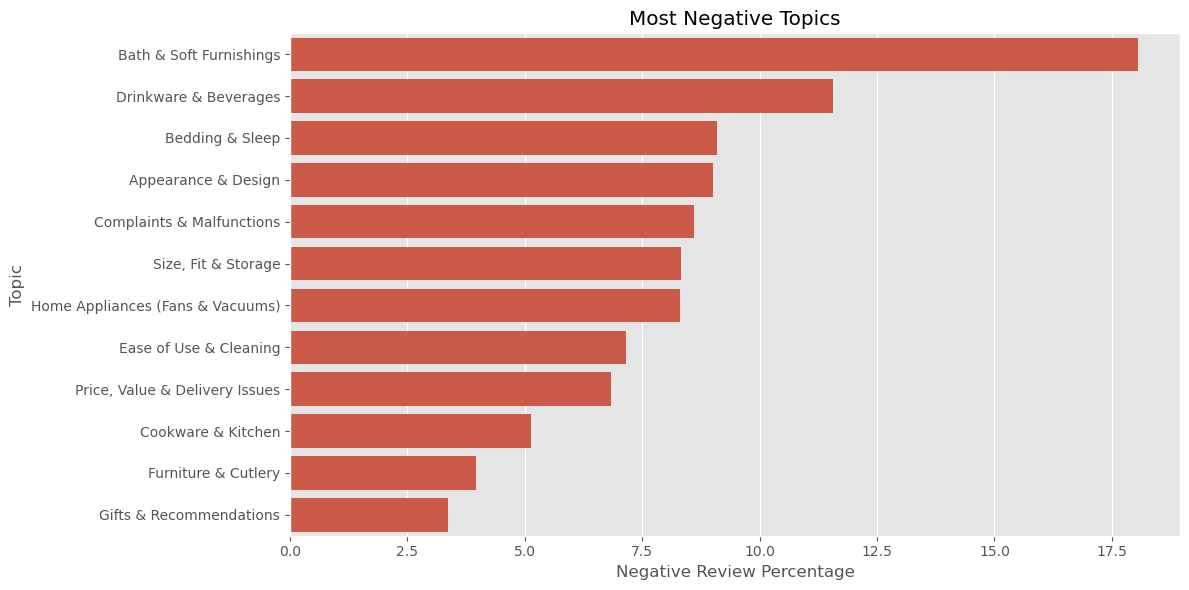

In [34]:
# Plot the most negative topics
plt.figure(figsize=(12, 6))

sns.barplot(
    data=negative_topic_share.reset_index(),
    x="negative",
    y="topic_label"
)

plt.title("Most Negative Topics")
plt.xlabel("Negative Review Percentage")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Helpful Votes by Topic

Helpful votes show which topics get the strongest reader response — which reviews other buyers actually find useful.

Голоса полезности показывают, какие темы вызывают наибольший отклик — какие отзывы другие покупатели реально считают полезными.

In [35]:
# Average helpful votes per topic
helpful_by_topic = reviews.groupby(
    "topic_label"
)["helpful_vote"].mean().sort_values(
    ascending=False
)

helpful_by_topic.round(2)

topic_label
Bath & Soft Furnishings             1.41
Complaints & Malfunctions           1.08
Size, Fit & Storage                 0.79
Bedding & Sleep                     0.78
Drinkware & Beverages               0.66
Appearance & Design                 0.66
Home Appliances (Fans & Vacuums)    0.65
Price, Value & Delivery Issues      0.61
Cookware & Kitchen                  0.48
Gifts & Recommendations             0.48
Furniture & Cutlery                 0.46
Ease of Use & Cleaning              0.43
Name: helpful_vote, dtype: float64

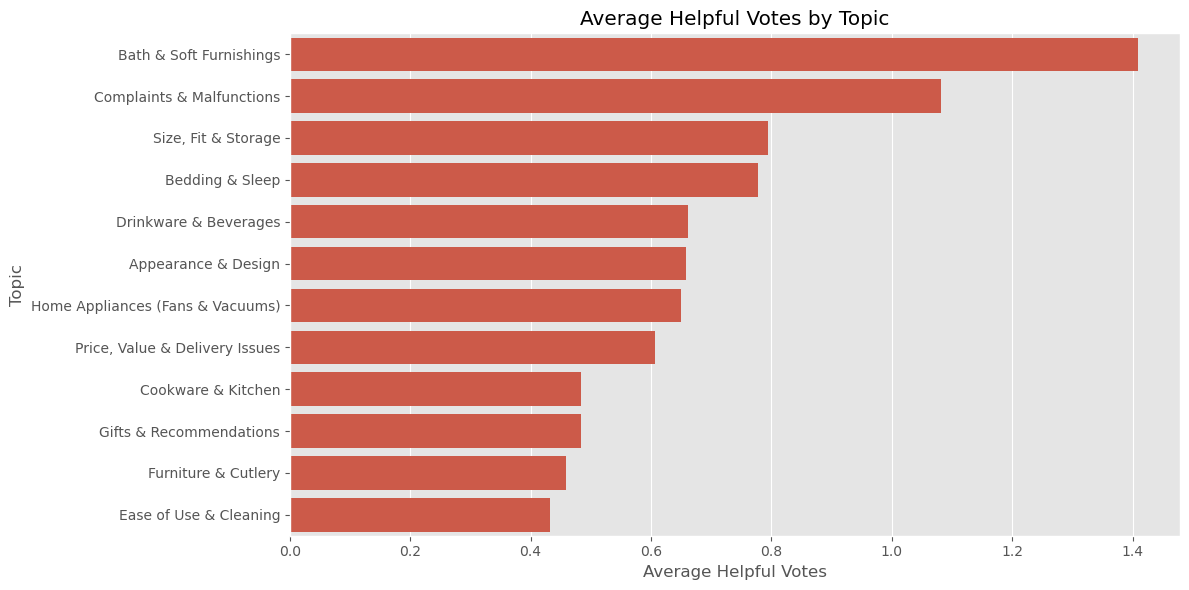

In [36]:
# Plot helpful votes per topic
plt.figure(figsize=(12, 6))

sns.barplot(
    x=helpful_by_topic.values,
    y=helpful_by_topic.index
)

plt.title("Average Helpful Votes by Topic")
plt.xlabel("Average Helpful Votes")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

Reader response varies noticeably between topics.

The most helpful votes on average go to `Home Appliances (Fans & Vacuums)` (1.58), `Furniture & Cutlery` (1.32), `Bedding & Sleep` (1.30), `Complaints & Malfunctions` (1.28) and `Cookware & Kitchen` (1.21) — technically complex or expensive products and problem reviews. Reviews with practical details and problem descriptions are the ones other buyers find useful.

The fewest votes go to `Gifts & Recommendations` (0.39), `Appearance & Design` (0.55) and `Size, Fit & Storage` (0.59) — typically shorter, more emotional reviews.

Отклик читателей заметно различается между темами.

Больше всего голосов полезности в среднем набирают `Home Appliances (Fans & Vacuums)` (1.58), `Furniture & Cutlery` (1.32), `Bedding & Sleep` (1.30), `Complaints & Malfunctions` (1.28) и `Cookware & Kitchen` (1.21) — технически сложные или дорогие товары и проблемные отзывы. Полезными другие покупатели считают отзывы с практическими деталями и описанием проблем.

Меньше всего откликов у `Gifts & Recommendations` (0.39), `Appearance & Design` (0.55) и `Size, Fit & Storage` (0.59) — это, как правило, более короткие и эмоциональные отзывы.

### Verified Purchase by Topic

We check how the share of verified purchases differs between topics.

Смотрим, как доля подтверждённых покупок различается между темами.

In [37]:
verified_by_topic = pd.crosstab(
    reviews["topic_label"],
    reviews["verified_purchase"],
    normalize="index"
) * 100

In [38]:
verified_by_topic = verified_by_topic.rename(
    columns={
        True: "verified",
        False: "non_verified"
    }
)

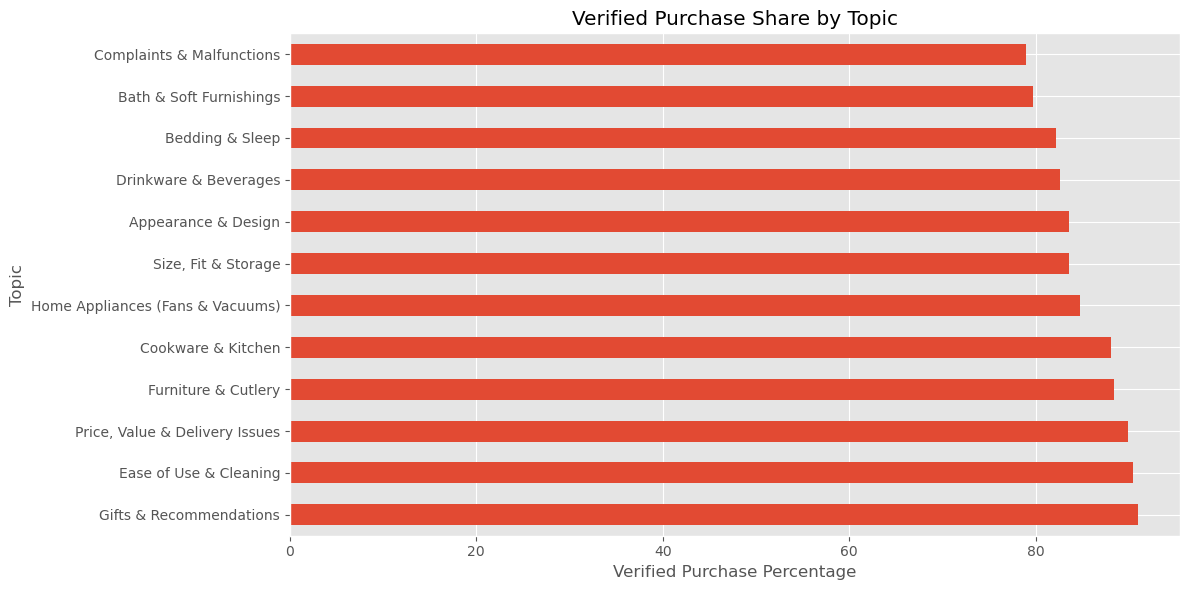

In [39]:
# Plot verified purchases per topic
verified_by_topic["verified"].sort_values(
    ascending=False
).plot(
    kind="barh",
    figsize=(12, 6)
)

plt.title("Verified Purchase Share by Topic")
plt.xlabel("Verified Purchase Percentage")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Sentiment Trends Over Time

We track how the shares of sentiment classes change month by month — whether customer satisfaction shifts over time.

Смотрим, как доли классов тональности меняются по месяцам — меняется ли удовлетворённость покупателей со временем.

In [40]:
# Normalized sentiment distribution over time
sentiment_time = pd.crosstab(
    reviews["year_month"],
    reviews["sentiment_label"],
    normalize="index"
) * 100

sentiment_time.head()

sentiment_label,negative,neutral,positive
year_month,,,
2019-01,9.702755,6.222813,84.074432
2019-02,10.740494,6.187458,83.072048
2019-03,10.425532,6.921986,82.652482
2019-04,10.188438,6.898754,82.912807
2019-05,10.010381,6.525285,83.464333


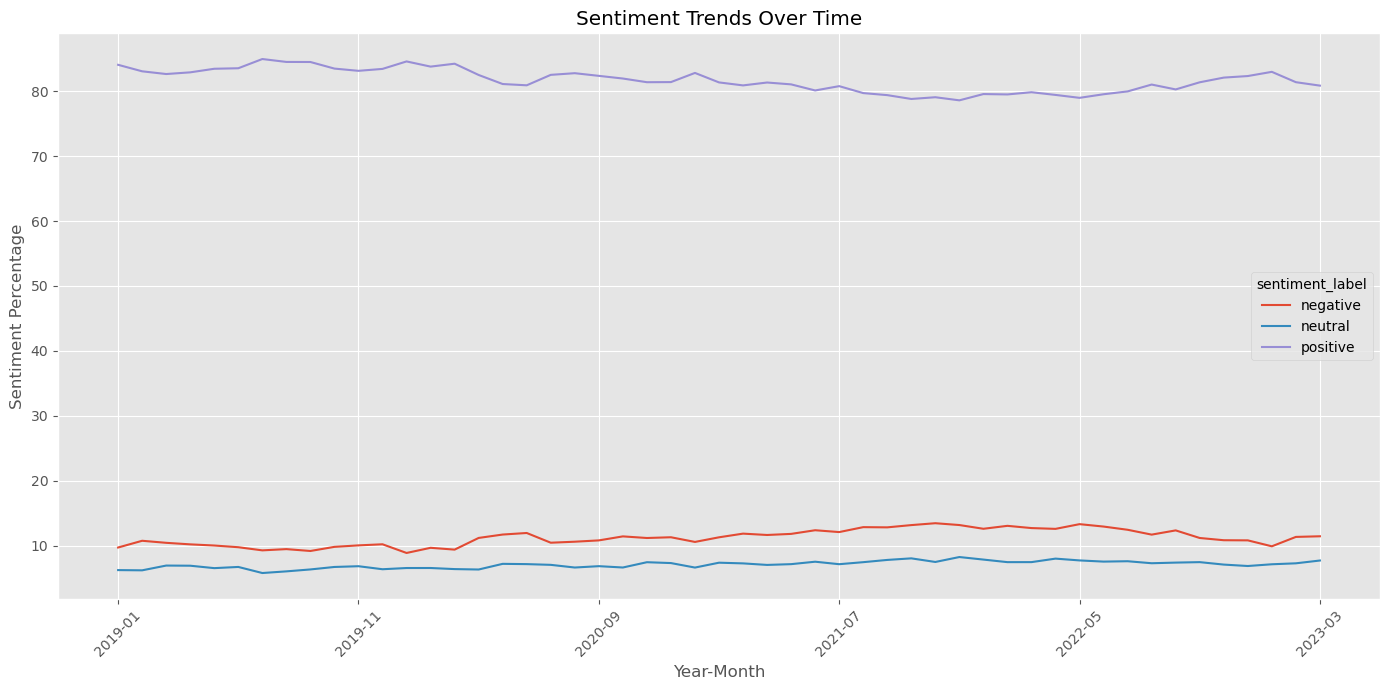

In [41]:
# Plot sentiment trends over time
sentiment_time.plot(
    figsize=(14, 7)
)

plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Sentiment Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight Fusion: conclusion

Combining sentiment, topics and metadata gives a compact picture:

- **Sentiment by topic:** the most problematic topics are `Price, Value & Delivery Issues` (41.8% negative) and `Complaints & Malfunctions` (34.1%); the most satisfied — `Gifts & Recommendations` and `Ease of Use & Cleaning` (>93% positive).
- **Helpful votes:** the strongest response goes to `Home Appliances`, `Furniture & Cutlery`, `Bedding & Sleep` and problem reviews — practical, problem-focused reviews are the most valuable to other buyers.
- **Verified purchase:** shares differ between topics.
- **Over time:** sentiment distribution is stable, with positive consistently dominating (~82%).

This combination pinpoints customer pain points (price/value/delivery, breakage and unmet expectations) and helps prioritize product and service improvements.

### Вывод по инсайтам

Связка тональности, тем и метаданных даёт компактную картину:

- **Тональность по темам:** самые проблемные — `Price, Value & Delivery Issues` (41.8% негатива) и `Complaints & Malfunctions` (34.1%); самые довольные — `Gifts & Recommendations` и `Ease of Use & Cleaning` (>93% позитива).
- **Голоса полезности:** наибольший отклик у `Home Appliances`, `Furniture & Cutlery`, `Bedding & Sleep` и проблемных отзывов — практичные отзывы с описанием проблем ценнее всего для других покупателей.
- **Подтверждённые покупки:** доли различаются между темами.
- **Во времени:** распределение тональности стабильно, позитив устойчиво доминирует (~82%).

Эта связка точечно находит болевые точки покупателей (цена/ценность/доставка, поломки и несоответствие ожиданиям) и помогает приоритизировать улучшения товара и сервиса.

## 3.4 Dashboard

Summary visualizations that bring the analysis together; the same views are implemented in the interactive Streamlit dashboard (`app.py`).

Сводные визуализации, собирающие анализ воедино; те же представления реализованы в интерактивном Streamlit-дашборде (`app.py`).

### Topic-Sentiment Heatmap

The heatmap shows the sentiment breakdown inside each topic and highlights the most problematic areas.

Heatmap показывает распределение тональности внутри каждой темы и подсвечивает самые проблемные области.

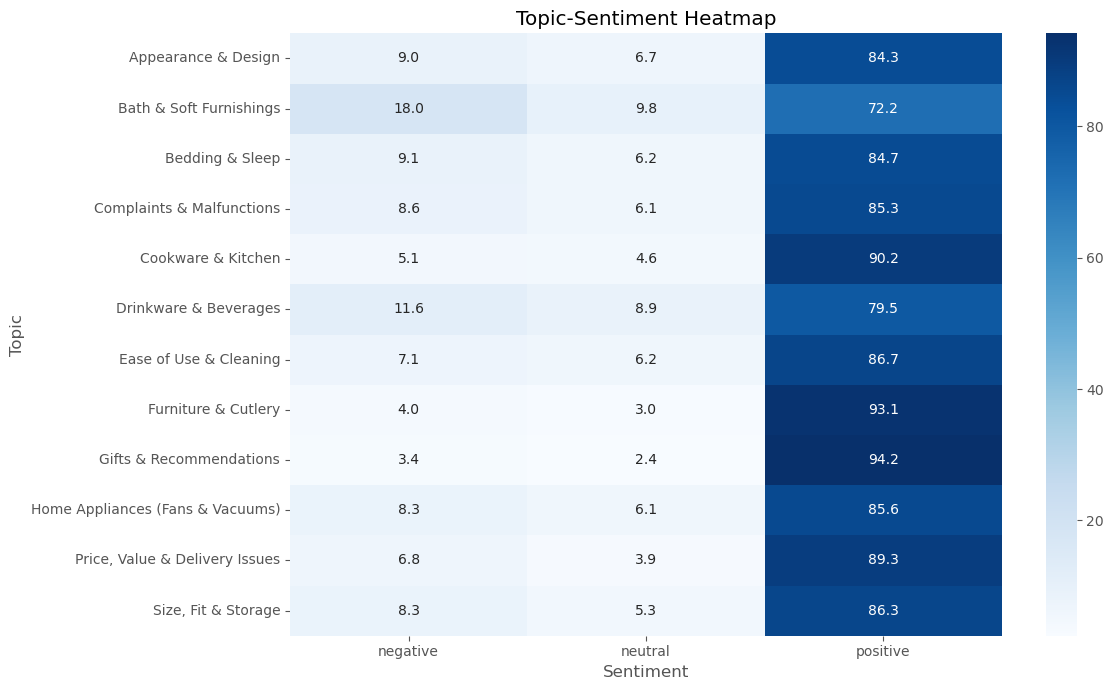

In [42]:
# Plot the sentiment breakdown per topic
plt.figure(figsize=(12, 7))

sns.heatmap(
    topic_sentiment,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Topic-Sentiment Heatmap")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Most Negative Topics

The bar chart ranks topics by their share of negative reviews — the main customer pain points.

Столбчатая диаграмма ранжирует темы по доле негативных отзывов — главные болевые точки покупателей.

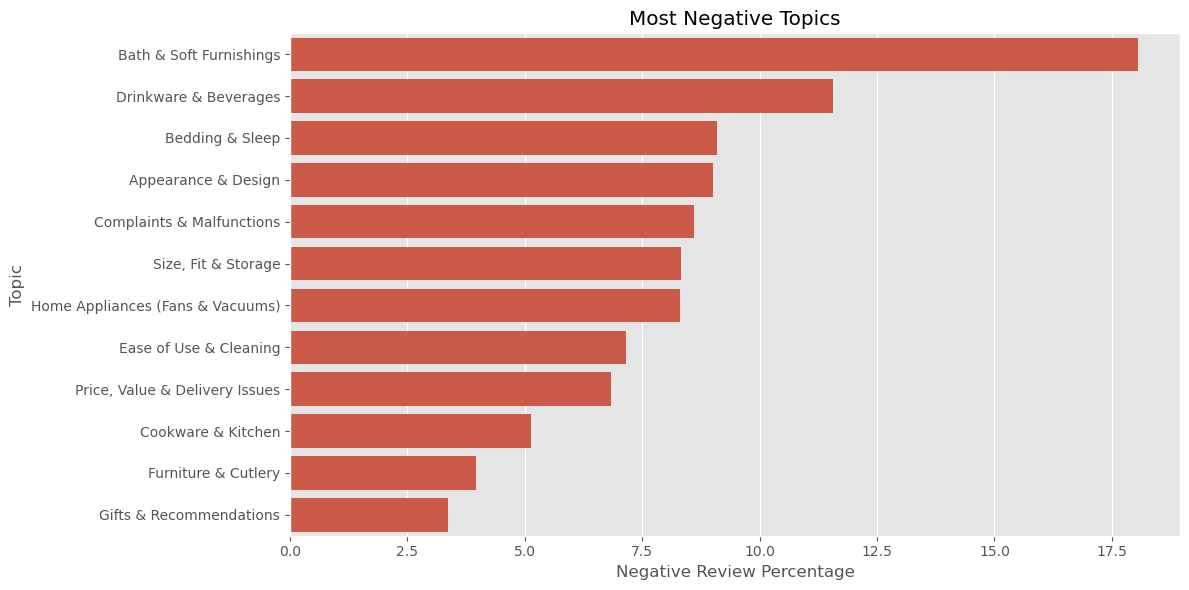

In [43]:
# Plot the most negative topics
plt.figure(figsize=(12, 6))

sns.barplot(
    data=negative_topic_share.reset_index(),
    x="negative",
    y="topic_label"
)

plt.title("Most Negative Topics")
plt.xlabel("Negative Review Percentage")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

### Sentiment Trends Over Time

The time series shows how the sentiment mix changes month by month.

Временной ряд показывает, как соотношение классов тональности меняется по месяцам.

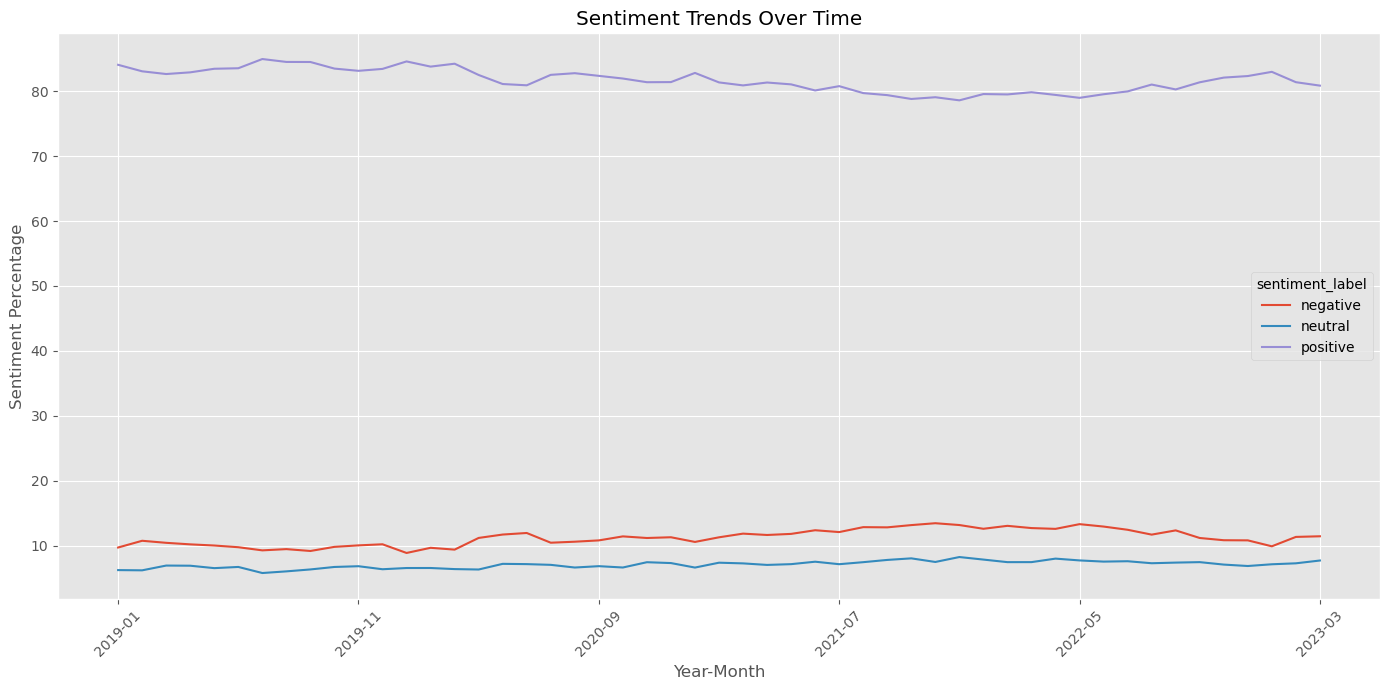

In [44]:
# Plot sentiment trends over time
sentiment_time.plot(
    figsize=(14, 7)
)

plt.title("Sentiment Trends Over Time")
plt.xlabel("Year-Month")
plt.ylabel("Sentiment Percentage")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.5 Extra: BERTopic vs LDA

LDA (section 3.1) builds topics from word counts and needs the number of topics set in advance (we used 12). Two limitations follow: it does not understand meaning (synonyms are different words to it), and it forces every review into some topic, even a vague one.

For comparison we add **BERTopic** — topic modeling on sentence embeddings. It turns each review into a meaning vector (the same transformer technique as in section 2.4), groups similar reviews, and decides the number of topics itself. Reviews that fit no group are kept aside as outliers, shown here as an "Other" category.

This is an exploratory section: LDA and the dashboard stay unchanged; the goal is to see what the modern approach adds.

Steps: review embeddings on GPU (MiniLM) → dimensionality reduction (UMAP) and clustering (HDBSCAN) inside BERTopic → characteristic words per topic (c-TF-IDF). Computed on a 50,000-review sample; results are cached in `models/bertopic_topics_*.csv` — if the files exist, the section just displays the tables.

LDA (раздел 3.1) строит темы по частотам слов и требует заранее задать их число (мы взяли 12). Отсюда два ограничения: он не понимает смысл (синонимы для него — разные слова) и относит каждый отзыв к какой-нибудь теме, даже расплывчатый.

Для сравнения добавляем **BERTopic** — выделение тем на векторах смысла предложений. Он превращает каждый отзыв в вектор-смысл (та же трансформерная техника, что в разделе 2.4), группирует похожие отзывы и сам определяет число тем. Отзывы, не похожие ни на одну группу, остаются отдельно — как «выбросы», показываем их категорией «Прочее».

Это исследовательский раздел: LDA и дашборд остаются без изменений; цель — посмотреть, что даёт современный подход.

Этапы: эмбеддинги отзывов на GPU (MiniLM) → снижение размерности (UMAP) и кластеризация (HDBSCAN) внутри BERTopic → характерные слова каждой темы (c-TF-IDF). Расчёт на выборке 50 000 отзывов; результат кэшируется в `models/bertopic_topics_*.csv` — при наличии файлов раздел просто показывает таблицы.

In [45]:
# Transformer-based topic modeling. Results are cached as CSV:
# if the tables exist we just display them, otherwise BERTopic runs on GPU.
AUTO_CSV = "models/bertopic_topics_auto.csv"
REDUCED_CSV = "models/bertopic_topics_reduced25.csv"

if not (os.path.exists(AUTO_CSV) and os.path.exists(REDUCED_CSV)):
    def light_clean(t):
        t = unescape(str(t))
        t = re.sub(r"<[^>]+>", " ", t)
        return re.sub(r"\s+", " ", t).strip()

    docs = (
        reviews["title"].fillna("").astype(str)
        + ". "
        + reviews["text"].fillna("").astype(str)
    )
    docs = docs.sample(n=min(50_000, len(docs)), random_state=42).map(light_clean).tolist()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    embedder = SentenceTransformer("all-MiniLM-L6-v2", device=device)
    embeddings = embedder.encode(docs, batch_size=256, show_progress_bar=True)

    vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=10)
    bertopic_model = BERTopic(
        embedding_model=embedder,
        vectorizer_model=vectorizer,
        min_topic_size=150,
        calculate_probabilities=False,
        verbose=True,
    )
    bertopic_model.fit_transform(docs, embeddings)
    bertopic_model.get_topic_info().to_csv(AUTO_CSV, index=False)
    bertopic_model.reduce_topics(docs, nr_topics=25)
    bertopic_model.get_topic_info().to_csv(REDUCED_CSV, index=False)

auto_topics = pd.read_csv(AUTO_CSV)
reduced_topics = pd.read_csv(REDUCED_CSV)


def topic_summary(df, title):
    n = int((df["Topic"] >= 0).sum())
    other = int(df.loc[df["Topic"] == -1, "Count"].iloc[0]) if (df["Topic"] == -1).any() else 0
    share = other / df["Count"].sum() * 100
    print(f"{title}: {n} topics + Other {other:,} ({share:.0f}%)")


topic_summary(auto_topics, "BERTopic (automatic)")
topic_summary(reduced_topics, "BERTopic (reduced to ~25)")

# Topic table of the reduced version; outliers shown as "Other"
view = reduced_topics[["Topic", "Count", "Name"]].copy()
view["Name"] = view.apply(
    lambda r: "Other (misc)" if r["Topic"] == -1 else r["Name"], axis=1
)
view


BERTopic (automatic): 66 topics + Other 23,170 (46%)
BERTopic (reduced to ~25): 24 topics + Other 23,170 (46%)


,Topic,Count,Name
0,-1,23170,Other (misc)
1,0,3533,0_pillow_soft_bed_sheets
2,1,3020,1_pan_eggs_pans_pot
3,2,2405,2_bags_bag_bowls_glasses
4,3,2235,3_tree_gift_frame_cute
5,4,1895,4_coffee_tea_cup_water
6,5,1736,5_chair_table_desk_chairs
7,6,1690,6_sturdy_shelves_shelf_storage
8,7,1664,7_curtain_curtains_shower_rod
9,8,1495,8_towels_mat_towel_soft


### LDA vs BERTopic: comparison

| | LDA (section 3.1) | BERTopic |
|---|---|---|
| Number of topics | 12, set manually | found automatically: ~65 (can be merged to ~25) |
| Based on | word counts, no meaning | sentence embeddings (meaning) |
| Topic granularity | broad, sometimes mixed | narrow and specific |
| Vague reviews | forced into some topic | set aside as "Other" (~46%) |

What the comparison showed:
- BERTopic splits what LDA merged: one LDA topic `Bedding & Sleep` becomes separate topics for pillows, mattresses, sheets and blankets; mixed `Furniture & Cutlery` becomes "chairs & tables" and "knives". Topics are specific enough to act on.
- BERTopic found ~65 topics on its own — much closer to the real product variety of Home & Kitchen than the hand-set 12.
- About 46% of reviews land in "Other": short generic reviews ("great", "love it", "works well") with no real topic. LDA would have forced them into categories; BERTopic honestly sets them aside.

The cost: BERTopic is heavier (GPU embeddings, extra libraries) and not deterministic by default (UMAP adds randomness). That is why LDA remains the project's main topic model: fast, reproducible, and sufficient for overview analytics. BERTopic is documented as the more precise alternative worth switching to when fine-grained, per-product segmentation is needed.

| | LDA (раздел 3.1) | BERTopic |
|---|---|---|
| Число тем | 12, задаётся вручную | определяется само: ~65 (можно свести к ~25) |
| Основа | частоты слов, без смысла | векторы смысла предложений |
| Гранулярность тем | широкие, иногда смешанные | узкие и конкретные |
| Расплывчатые отзывы | принудительно получают тему | вынесены в «Прочее» (~46%) |

Что показало сравнение:
- BERTopic разделяет то, что LDA объединял: одна тема `Bedding & Sleep` распадается на подушки, матрасы, простыни и одеяла; смешанная `Furniture & Cutlery` — на «стулья и столы» и «ножи». Темы достаточно конкретны для практических решений.
- BERTopic сам нашёл ~65 тем — это гораздо ближе к реальному разнообразию товаров Home & Kitchen, чем заданные вручную 12.
- Около 46% отзывов попадают в «Прочее»: короткие общие отзывы («great», «love it», «works well») без выраженной темы. LDA распределил бы их принудительно; BERTopic честно выносит отдельно.

Цена: BERTopic тяжелее (эмбеддинги на GPU, дополнительные библиотеки) и не детерминирован по умолчанию (UMAP вносит случайность). Поэтому основной моделью тем в проекте остаётся LDA: быстрый, воспроизводимый и достаточный для обзорной аналитики. BERTopic зафиксирован как более точная альтернатива, к которой стоит переходить, когда нужна детальная сегментация по конкретным товарам.